In [6]:
pip install pandas pyarrow gensim nltk scikit-learn matplotlib seaborn tqdm

In [7]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
import pandas as pd
import numpy as np
import nltk
import re
from tqdm import tqdm

from gensim.models import Word2Vec, FastText
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
from google.colab import drive
drive.mount('/content/drive')

# Correct path (your case)
base_path = "/content/drive/MyDrive/imdp"

train = pd.read_parquet(f"{base_path}/train.parquet")
unsup = pd.read_parquet(f"{base_path}/unsupervised.parquet")

# Combine data for better embeddings
data = pd.concat([train['text'], unsup['text']])

# Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

# Tokenization
def tokenize(text):
    return nltk.word_tokenize(text)

data = data.apply(clean_text)
sentences = data.apply(tokenize).tolist()

print("Sample:", sentences[0][:10])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sample: ['i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because']


In [10]:
from gensim.models import Word2Vec, FastText

In [11]:
import gc
gc.collect()

# 🔥 IMPORTANT: re-import after restart
from gensim.models import Word2Vec, FastText
import numpy as np

# ---- Word2Vec CBOW ----
w2v_cbow = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=20,
    sg=0,
    workers=4
)

# ---- Word2Vec Skip-Gram ----
w2v_sg = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=20,
    sg=1,
    workers=4
)

# ---- FastText ----
fasttext_model = FastText(
    sentences,
    vector_size=100,
    window=5,
    min_count=20,
    workers=4
)

print("Word2Vec & FastText trained ✅")


# ---- Load GloVe ----
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

def load_glove(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove = load_glove("glove.6B.100d.txt")

print("GloVe loaded ✅")

Word2Vec & FastText trained ✅
GloVe loaded ✅


CBOW good vs bad: 0.8056102
SkipGram good vs bad: 0.7604255
FastText good vs bad: 0.7679899
GloVe good vs bad: 0.77027977

CBOW: [('bad', 0.8056102395057678), ('decent', 0.788628101348877), ('great', 0.7835580706596375), ('cool', 0.7109478712081909), ('nice', 0.6847223043441772), ('fine', 0.6809581518173218), ('terrible', 0.6603793501853943), ('lousy', 0.6583870053291321), ('passable', 0.6546682715415955), ('solid', 0.6488635540008545)]

SkipGram: [('decent', 0.8200021386146545), ('great', 0.7805618047714233), ('bad', 0.7604253888130188), ('goodand', 0.7348255515098572), ('nice', 0.6986147165298462), ('badbut', 0.6981755495071411), ('fine', 0.6906424164772034), ('goodbut', 0.6894732117652893), ('halfdecent', 0.6824823617935181), ('goodthis', 0.6603075265884399)]

FastText: [('goodi', 0.9188891053199768), ('goodbad', 0.9172002673149109), ('goodbut', 0.8751513957977295), ('goodand', 0.858875036239624), ('goody', 0.849585235118866), ('goodthis', 0.8307812213897705), ('sobaditsgood', 0.824

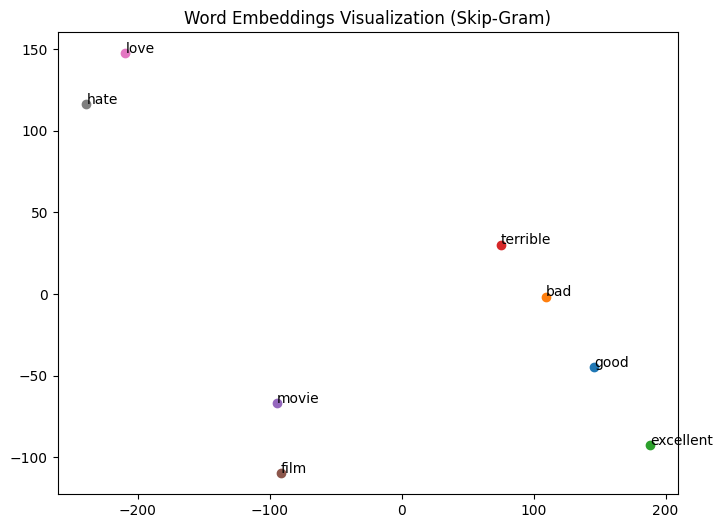

In [13]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ---- Safe similarity ----
def safe_similarity(model, w1, w2):
    try:
        return model.wv.similarity(w1, w2)
    except:
        return "word not in vocab"

print("CBOW good vs bad:", safe_similarity(w2v_cbow, "good", "bad"))
print("SkipGram good vs bad:", safe_similarity(w2v_sg, "good", "bad"))
print("FastText good vs bad:", safe_similarity(fasttext_model, "good", "bad"))

# ---- GloVe similarity ----
def glove_similarity(w1, w2):
    if w1 in glove and w2 in glove:
        return np.dot(glove[w1], glove[w2]) / (
            np.linalg.norm(glove[w1]) * np.linalg.norm(glove[w2])
        )
    return "word not in glove"

print("GloVe good vs bad:", glove_similarity("good", "bad"))


# ---- Top 10 similar words ----
def safe_top(model, word):
    try:
        return model.wv.most_similar(word, topn=10)
    except:
        return "word not in vocab"

print("\nCBOW:", safe_top(w2v_cbow, "good"))
print("\nSkipGram:", safe_top(w2v_sg, "good"))
print("\nFastText:", safe_top(fasttext_model, "good"))


# ---- GloVe top similar (optimized subset) ----
def glove_top_similar(word, topn=10):
    if word not in glove:
        return "word not in glove"

    keys = list(glove.keys())[:50000]  # speed optimization

    sims = {}
    for w in keys:
        sims[w] = np.dot(glove[word], glove[w]) / (
            np.linalg.norm(glove[word]) * np.linalg.norm(glove[w])
        )

    return sorted(sims.items(), key=lambda x: x[1], reverse=True)[1:topn+1]

print("\nGloVe:", glove_top_similar("good"))


# ---- TSNE Visualization (FIXED) ----
words = ["good","bad","excellent","terrible","movie","film","love","hate"]

vectors = []
labels = []

for w in words:
    if w in w2v_sg.wv:
        vectors.append(w2v_sg.wv[w])
        labels.append(w)

# ✅ Convert to numpy array (FIX)
vectors = np.array(vectors)

if len(vectors) > 2:
    tsne = TSNE(n_components=2, random_state=42, perplexity=2)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(8,6))
    for i, word in enumerate(labels):
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0]+0.3, reduced[i,1]+0.3, word)

    plt.title("Word Embeddings Visualization (Skip-Gram)")
    plt.show()
else:
    print("Not enough words for TSNE")